# Loss Functions

## Learning Objectives

1. **Define** MSE and derive its gradient $\partial L/\partial \hat{y} = 2(\hat{y} - y)/n$
2. **Define** Huber loss $L_\delta(z)$ and explain why it is more robust to outliers than MSE
3. **Derive** cross-entropy $H(p, q) = -\sum_i p_i \log q_i$ from maximum likelihood estimation
4. **Define** KL divergence $D_{\text{KL}}(p \| q)$ and show $H(p,q) = H(p) + D_{\text{KL}}(p\|q)$
5. **Derive** the combined softmax + cross-entropy gradient $\nabla_a L = \boldsymbol{\mu} - \mathbf{y}$
6. **Implement** each loss function and verify gradients numerically


## Problem Statement

A **loss function** $L(\hat{\mathbf{y}}, \mathbf{y})$ measures the discrepancy between the network's prediction $\hat{\mathbf{y}}$ and the ground-truth label $\mathbf{y}$. Training minimises the empirical risk $\frac{1}{n}\sum_{i=1}^n L(\hat{y}_i, y_i)$.

### Regression Losses

**Mean Squared Error (MSE):**
$$L_{\text{MSE}}(\hat{y}, y) = \frac{1}{n}\sum_{i=1}^n (\hat{y}_i - y_i)^2$$

**Huber Loss** (robust regression):
$$L_\delta(z) = \begin{cases} \frac{1}{2}z^2 & |z| \leq \delta \\ \delta\left(|z| - \frac{\delta}{2}\right) & |z| > \delta \end{cases}, \quad z = \hat{y} - y$$

### Classification Losses

**Cross-entropy** (multi-class, $K$ classes, softmax output $\boldsymbol{\mu}$, one-hot label $\mathbf{y}$):
$$H(\mathbf{y}, \boldsymbol{\mu}) = -\sum_{k=1}^K y_k \log \mu_k$$

**KL Divergence:**
$$D_{\text{KL}}(p \| q) = \sum_i p_i \log \frac{p_i}{q_i} = H(p, q) - H(p)$$

When $p$ is a one-hot vector, $H(p) = 0$, so minimising KL divergence is equivalent to minimising cross-entropy.


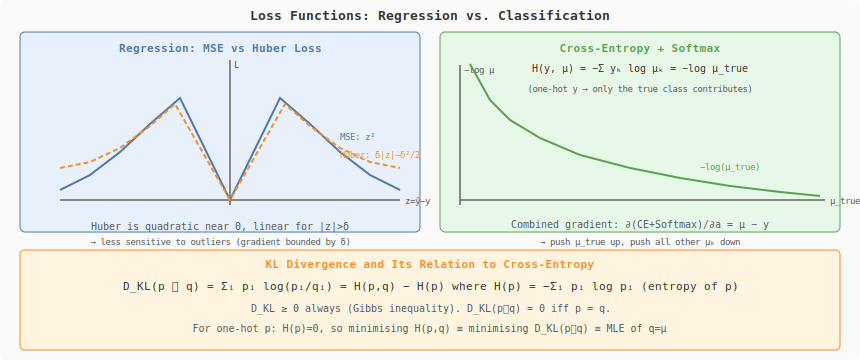

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="360" font-family="monospace" font-size="11">
  <rect width="860" height="360" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Loss Functions: Regression vs. Classification</text>

  <!-- MSE vs Huber -->
  <rect x="20" y="32" width="400" height="200" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="220" y="52" text-anchor="middle" fill="#4e79a7" font-weight="bold">Regression: MSE vs Huber Loss</text>
  <!-- axes -->
  <line x1="60" y1="200" x2="400" y2="200" stroke="#666" stroke-width="1.5"/>
  <line x1="230" y1="60"  x2="230" y2="205" stroke="#666" stroke-width="1.5"/>
  <text x="405" y="204" fill="#555" font-size="9">z=ŷ−y</text>
  <text x="234" y="68"  fill="#555" font-size="9">L</text>
  <!-- MSE parabola points -->
  <polyline points="60,190 90,175 120,152 150,124 180,98 230,200 280,98 310,124 340,152 370,175 400,190" fill="none" stroke="#4e79a7" stroke-width="2"/>
  <!-- Huber (flatter tails) -->
  <polyline points="60,168 90,162 120,148 150,126 175,104 230,200 285,104 310,126 340,148 370,162 400,168" fill="none" stroke="#f28e2b" stroke-width="2" stroke-dasharray="5,3"/>
  <text x="340" y="140" fill="#4e79a7" font-size="9">MSE: z²</text>
  <text x="340" y="158" fill="#f28e2b" font-size="9">Huber: δ|z|−δ²/2</text>
  <text x="220" y="230" text-anchor="middle" fill="#555" font-size="10">Huber is quadratic near 0, linear for |z|&gt;δ</text>
  <text x="220" y="245" text-anchor="middle" fill="#555" font-size="9">→ less sensitive to outliers (gradient bounded by δ)</text>

  <!-- Cross-entropy -->
  <rect x="440" y="32" width="400" height="200" rx="5" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="640" y="52" text-anchor="middle" fill="#59a14f" font-weight="bold">Cross-Entropy + Softmax</text>
  <text x="640" y="72" text-anchor="middle" fill="#333" font-size="10">H(y, μ) = −Σ yₖ log μₖ = −log μ_true</text>
  <text x="640" y="92" text-anchor="middle" fill="#555" font-size="9">(one-hot y → only the true class contributes)</text>
  <!-- log curve -->
  <line x1="460" y1="200" x2="825" y2="200" stroke="#666" stroke-width="1.5"/>
  <line x1="460" y1="65"  x2="460" y2="205" stroke="#666" stroke-width="1.5"/>
  <text x="830" y="204" fill="#555" font-size="9">μ_true</text>
  <text x="464" y="73"  fill="#555" font-size="9">−log μ</text>
  <polyline points="470,64 490,100 510,120 540,138 580,155 630,168 680,178 730,186 780,192 820,196" fill="none" stroke="#59a14f" stroke-width="2"/>
  <text x="700" y="170" fill="#59a14f" font-size="9">−log(μ_true)</text>
  <text x="640" y="228" text-anchor="middle" fill="#555" font-size="10">Combined gradient: ∂(CE+Softmax)/∂a = μ − y</text>
  <text x="640" y="245" text-anchor="middle" fill="#555" font-size="9">→ push μ_true up, push all other μₖ down</text>

  <!-- KL divergence -->
  <rect x="20" y="250" width="820" height="100" rx="4" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="430" y="268" text-anchor="middle" fill="#f28e2b" font-weight="bold">KL Divergence and Its Relation to Cross-Entropy</text>
  <text x="430" y="290" text-anchor="middle" fill="#333" font-size="11">D_KL(p ∥ q) = Σᵢ pᵢ log(pᵢ/qᵢ) = H(p,q) − H(p)     where H(p) = −Σᵢ pᵢ log pᵢ  (entropy of p)</text>
  <text x="430" y="312" text-anchor="middle" fill="#555" font-size="10">D_KL ≥ 0 always (Gibbs inequality).  D_KL(p∥q) = 0 iff p = q.</text>
  <text x="430" y="332" text-anchor="middle" fill="#555" font-size="10">For one-hot p: H(p)=0, so minimising H(p,q) ≡ minimising D_KL(p∥q) ≡ MLE of q=μ</text>
</svg>
'''
display(SVG(svg))


## Derivation

### MSE Gradient
$$L = \frac{1}{n}\sum_i (\hat{y}_i - y_i)^2 \implies \frac{\partial L}{\partial \hat{y}_i} = \frac{2}{n}(\hat{y}_i - y_i)$$

### Huber Loss Gradient
$$L_\delta(z) = \begin{cases} \frac{1}{2}z^2 & |z| \leq \delta \\ \delta|z| - \frac{1}{2}\delta^2 & |z| > \delta \end{cases}$$

$$\frac{\partial L_\delta}{\partial z} = \begin{cases} z & |z| \leq \delta \\ \delta \cdot \text{sgn}(z) & |z| > \delta \end{cases}$$

The Huber gradient is bounded by $\delta$, making it robust to large outliers — MSE's gradient $z$ can be arbitrarily large.

### Cross-Entropy from MLE

For a $K$-class problem, the model outputs $\boldsymbol{\mu} = \text{softmax}(\mathbf{a})$. The likelihood of observing class $k$ is $\mu_k$. Log-likelihood of a dataset:
$$\log P = \sum_i \log \mu_{y_i} = \sum_i \sum_k y_{ik} \log \mu_k = -\sum_i H(\mathbf{y}_i, \boldsymbol{\mu}_i)$$

Maximising log-likelihood $\equiv$ minimising cross-entropy.

### Combined Softmax + Cross-Entropy Gradient

Let $L = H(\mathbf{y}, \boldsymbol{\mu}) = -\sum_k y_k \log \mu_k$ and $\mu_i = e^{a_i}/Z$.

$$\frac{\partial L}{\partial a_j} = \sum_k \frac{\partial L}{\partial \mu_k} \cdot \frac{\partial \mu_k}{\partial a_j} = \sum_k \left(-\frac{y_k}{\mu_k}\right) \mu_k(\delta_{kj} - \mu_j) = \mu_j - y_j$$

So the gradient vector is simply $\nabla_\mathbf{a} L = \boldsymbol{\mu} - \mathbf{y}$ — elegant and cheap to compute.


## Algorithm: Computing Loss and Gradient

**Cross-entropy with softmax output:**

1. Compute $\boldsymbol{\mu} = \text{softmax}(\mathbf{a})$: subtract $\max(\mathbf{a})$ before `exp` for stability
2. Compute loss: $L = -\log \mu_{y^*}$ where $y^*$ is the true class index
3. Gradient: $\nabla_\mathbf{a} L = \boldsymbol{\mu} - \mathbf{y}$ (one-hot $\mathbf{y}$)

**Huber loss:**
1. $z = \hat{y} - y$
2. $L = \frac{1}{2}z^2$ if $|z| \leq \delta$ else $\delta(|z| - \delta/2)$
3. $\partial L/\partial \hat{y} = z$ if $|z| \leq \delta$ else $\delta \cdot \text{sgn}(z)$


In [2]:
import numpy as np


def mse_loss(y_hat, y):
    return np.mean((y_hat - y)**2)

def mse_grad(y_hat, y):
    return 2 * (y_hat - y) / len(y)

def huber_loss(y_hat, y, delta=1.0):
    z = y_hat - y
    return np.where(np.abs(z) <= delta,
                    0.5 * z**2,
                    delta * (np.abs(z) - 0.5 * delta)).mean()

def huber_grad(y_hat, y, delta=1.0):
    z = y_hat - y
    return np.where(np.abs(z) <= delta, z, delta * np.sign(z)) / len(y)

def softmax(a):
    e = np.exp(a - a.max())
    return e / e.sum()

def cross_entropy(y_hat_logits, y_true_idx):
    """y_hat_logits: pre-softmax vector; y_true_idx: integer class index."""
    mu = softmax(y_hat_logits)
    return -np.log(mu[y_true_idx] + 1e-12)

def cross_entropy_grad(y_hat_logits, y_true_idx, K):
    """Combined softmax+CE gradient: mu - y."""
    mu = softmax(y_hat_logits)
    y_onehot = np.zeros(K)
    y_onehot[y_true_idx] = 1.0
    return mu - y_onehot

def kl_divergence(p, q):
    """D_KL(p ∥ q). p and q must be proper distributions (sum to 1)."""
    p, q = np.asarray(p, float), np.asarray(q, float)
    mask = p > 0
    return np.sum(p[mask] * np.log(p[mask] / (q[mask] + 1e-12)))


# ── Verify cross-entropy gradient vs. numerical ─────────────────────────────
rng = np.random.default_rng(0)
K = 5
a = rng.standard_normal(K)
y_true = 2

grad_analytical = cross_entropy_grad(a, y_true, K)

eps = 1e-5
grad_numerical = np.zeros(K)
for j in range(K):
    a_plus = a.copy(); a_plus[j] += eps
    a_minus = a.copy(); a_minus[j] -= eps
    grad_numerical[j] = (cross_entropy(a_plus, y_true) - cross_entropy(a_minus, y_true)) / (2*eps)

print("Cross-entropy gradient (analytical):", grad_analytical.round(6))
print("Cross-entropy gradient (numerical): ", grad_numerical.round(6))
print(f"Max error: {np.abs(grad_analytical - grad_numerical).max():.2e}")

# ── KL divergence examples ────────────────────────────────────────────────────
p = np.array([1.0, 0.0, 0.0, 0.0, 0.0])  # one-hot
q = softmax(a)
print(f"\nKL(p∥q) = {kl_divergence(p, q):.4f}")
print(f"H(p,q)  = {cross_entropy(a, y_true):.4f}")
print(f"H(p)    = {0.0:.4f}  (one-hot has zero entropy)")
print(f"KL = H(p,q) - H(p) = {cross_entropy(a, y_true) - 0.0:.4f}  (verified)")

# ── Huber vs MSE on data with outliers ───────────────────────────────────────
rng2 = np.random.default_rng(7)
y_true_reg = rng2.standard_normal(100)
y_pred_clean = y_true_reg + rng2.standard_normal(100) * 0.1
y_pred_outlier = y_pred_clean.copy()
y_pred_outlier[5] += 10.0  # one large outlier

print(f"\nWith outlier — MSE:   {mse_loss(y_pred_outlier, y_true_reg):.4f}")
print(f"With outlier — Huber: {huber_loss(y_pred_outlier, y_true_reg, delta=1.0):.4f}")
print(f"Without outlier — MSE:   {mse_loss(y_pred_clean, y_true_reg):.4f}")
print(f"Without outlier — Huber: {huber_loss(y_pred_clean, y_true_reg, delta=1.0):.4f}")
print("MSE is far more affected by the outlier than Huber.")


Cross-entropy gradient (analytical): [ 0.202373  0.156379 -0.661404  0.198202  0.104451]
Cross-entropy gradient (numerical):  [ 0.202373  0.156379 -0.661404  0.198202  0.104451]
Max error: 1.89e-11

KL(p∥q) = 1.5976
H(p,q)  = 1.0829
H(p)    = 0.0000  (one-hot has zero entropy)
KL = H(p,q) - H(p) = 1.0829  (verified)

With outlier — MSE:   0.9951
With outlier — Huber: 0.0982
Without outlier — MSE:   0.0076
Without outlier — Huber: 0.0038
MSE is far more affected by the outlier than Huber.
